# exp174 — contacts-and-crops-v1 structure predictions vs ground truth

Interactive 3D viewer for [issue #174](https://github.com/Open-Athena/MarinFold/issues/174).

Pick a protein and an inference plan; the prediction and the experimental
structure are superimposed and drawn together, with that protein's metrics
underneath.

**Reading the colours.** The prediction is coloured by the resolution tier the
document actually reached, which is the thing this format lives or dies on:

* **blue** — refined by a Pass-2 crop (0.1 Å tenths available)
* **orange** — Pass-1 only, so the model localized the atom to a **10 Å box**
  and it is drawn at that box's centre
* **grey** — the ground truth

An orange atom sitting ~5 Å from grey is not a model error; it is the format's
coarse tier doing exactly what it says. The `box10` row of the ceiling table
(lDDT 0.32 even when *every* box is correct) is what that costs.

Runs anonymously — no login, no token. Open in Colab straight from GitHub.

In [1]:
# Colab has none of these; locally you probably already do.
%pip install -q py3Dmol biotite pandas requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
import io, tarfile
from pathlib import Path
from urllib.parse import quote

import pandas as pd
import requests

RESOLVE = "https://huggingface.co/buckets/open-athena/MarinFold/resolve"
PREFIX = "data/exp174-structural-eval"
CACHE = Path("exp174_data"); CACHE.mkdir(exist_ok=True)


def fetch(name: str) -> Path:
    """Download one published artifact (cached), anonymously.

    The bucket path is quoted whole (``safe=""``), so its slashes become
    %2F — the form the resolve endpoint expects.
    """
    local = CACHE / name.replace("/", "_")
    if not local.exists():
        path = quote(f"{PREFIX}/{name}", safe="")
        response = requests.get(f"{RESOLVE}/{path}", timeout=600)
        response.raise_for_status()
        local.write_bytes(response.content)
    return local


def fetch_structures(name: str) -> Path:
    """Download and unpack a structure tarball, returning its root."""
    root = CACHE / name.replace("/", "_").replace(".tar.gz", "")
    if not root.exists():
        with tarfile.open(fetch(name)) as tar:
            tar.extractall(root)
    return root


# scores_all.csv carries every scored run, including the model-free
# quantization baselines from the ceiling table. Only the runs below have their
# structures published, so only those can be viewed in 3D.
VIEWABLE = [
    "oracle-doc",
    "e2-cc1mix5-step50000",
    "e1-cc1mix5-step50000",
    "f-cc1mix5-step50000",
    "f-3way-step20000",
    "c-cc1mix5-step50000",
    "a-cc1mix5-step50000",
    "a-3way-step20000",
]

scores = pd.read_csv(fetch("results/scores_all.csv"))
gt_root = fetch_structures("gt/gt_structures.tar.gz")
print(f"{len(scores):,} scored (record, run) rows across {scores.run.nunique()} runs")
print("viewable in 3D:", [r for r in VIEWABLE if r in set(scores.run)])

/tmp/ipykernel_2582195/3538579681.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(root)


12,188 scored (record, run) rows across 22 runs
viewable in 3D: ['oracle-doc', 'e2-cc1mix5-step50000', 'e1-cc1mix5-step50000', 'f-cc1mix5-step50000', 'f-3way-step20000', 'c-cc1mix5-step50000', 'a-cc1mix5-step50000', 'a-3way-step20000']


## Aggregate — where each plan lands against the format's ceiling

In [3]:
summary = (
    scores[scores.run.isin(VIEWABLE)]
    .groupby("run")
    .agg(n=("record_id", "size"),
         atom_coverage=("atom_coverage", "mean"),
         lddt=("lddt_all", "mean"),
         lddt_ca=("lddt_ca", "mean"),
         tm_score=("tm_score", "mean"),
         rmsd_ca=("rmsd_ca", "median"))
    .sort_values("lddt", ascending=False)
)
summary.style.format({"atom_coverage": "{:.3f}", "lddt": "{:.3f}", "lddt_ca": "{:.3f}",
                      "tm_score": "{:.3f}", "rmsd_ca": "{:.2f}"})

,n,atom_coverage,lddt,lddt_ca,tm_score,rmsd_ca
run,,,,,,
f-3way-step20000,554,0.998,0.294,0.323,0.279,16.48
f-cc1mix5-step50000,554,0.999,0.290,0.319,0.277,16.28
oracle-doc,554,0.769,0.290,0.300,0.537,4.16
e2-cc1mix5-step50000,554,0.772,0.278,0.291,0.522,4.33
c-cc1mix5-step50000,554,0.935,0.223,0.246,0.245,16.55
e1-cc1mix5-step50000,554,0.754,0.161,0.169,0.222,12.96
a-3way-step20000,554,0.753,0.144,0.160,0.197,16.85
a-cc1mix5-step50000,554,0.758,0.141,0.158,0.193,16.62


## Pick a protein

`oracle-document` is the ceiling row: a **real document generated from the
ground truth** and decoded by the same code path. It is what a perfect model
would score, so it is the honest comparator for every model row.

In [4]:
RUN = "f-cc1mix5-step50000"      # any name from VIEWABLE above
TOP_N = 25

if RUN not in VIEWABLE:
    raise SystemExit(f"{RUN!r} has no published structures; pick from {VIEWABLE}")

ranked = (
    scores[(scores.run == RUN) & (scores.status == "ok")]
    .sort_values("lddt_all", ascending=False)
    .loc[:, ["record_id", "L", "atom_coverage", "frac_refined_of_gt",
             "lddt_all", "lddt_ca", "tm_score", "rmsd_ca"]]
)
print(f"{RUN}: {len(ranked)} scored; best {TOP_N} by lDDT")
ranked.head(TOP_N).style.format(precision=3)

f-cc1mix5-step50000: 554 scored; best 25 by lDDT


,record_id,L,atom_coverage,frac_refined_of_gt,lddt_all,lddt_ca,tm_score,rmsd_ca
6977,denovo_pdb/7sq4_A,48,1.000,1.000,0.650,0.753,0.456,6.694
6991,denovo_pdb/8bcs_A,49,1.000,1.000,0.647,0.682,0.674,2.702
6997,denovo_pdb/8ch0_A,136,0.999,0.999,0.609,0.636,0.594,4.619
7141,denovo_pdb/3v1a_A,48,1.000,1.000,0.595,0.664,0.637,2.912
6751,denovo_pdb/2avp_A,68,0.998,0.998,0.584,0.648,0.516,4.273
6762,denovo_pdb/2xen_A,91,1.000,1.000,0.582,0.595,0.615,3.437
7001,denovo_pdb/8cmq_A,136,1.000,1.000,0.579,0.619,0.528,7.060
6761,denovo_pdb/2wqh_A,104,1.000,1.000,0.565,0.614,0.493,5.891
6755,denovo_pdb/2hyz_A,136,0.999,0.999,0.559,0.604,0.497,6.529
6748,denovo_pdb/1mj0_A,156,0.999,0.999,0.554,0.589,0.596,4.788


In [5]:
RECORD_ID = ranked.iloc[0].record_id     # or e.g. "foldbench100/7t9r_A"
print("showing", RECORD_ID)

showing denovo_pdb/7sq4_A


## 3D view — prediction (blue = refined, orange = box-only) vs ground truth (grey)

In [6]:
import numpy as np
import py3Dmol
from biotite.structure import superimpose
from biotite.structure.io.pdb import PDBFile

REFINED_MAX_SIGMA = 1.0   # B-factor is the predictor's positional sigma in A


def read(path):
    return PDBFile.read(str(path)).get_structure(model=1, extra_fields=["b_factor"])


def load_pair(run, record_id):
    dataset, stem = record_id.split("/")
    pred_root = fetch_structures(f"results/pred_{run}.tar.gz")
    pred = read(next(pred_root.rglob(f"{dataset}/{stem}.pdb")))
    gt = read(gt_root / "gt_structures" / dataset / f"{stem}.pdb")

    # Superimpose the prediction onto the ground truth over their common atoms.
    # Each document lives in its own random frame, so this is required, not
    # cosmetic -- and it is exactly what the RMSD metric does.
    gt_keys = {(r, a): i for i, (r, a) in enumerate(zip(gt.res_id.tolist(), gt.atom_name.tolist()))}
    pred_rows, gt_rows = [], []
    for i, (r, a) in enumerate(zip(pred.res_id.tolist(), pred.atom_name.tolist())):
        if (r, a) in gt_keys:
            pred_rows.append(i); gt_rows.append(gt_keys[(r, a)])
    if len(pred_rows) < 3:
        raise ValueError(f"only {len(pred_rows)} common atoms - nothing to superimpose")
    _, transform = superimpose(gt[gt_rows], pred[pred_rows])
    return transform.apply(pred), gt, len(pred_rows)


def to_pdb_string(array, mask=None):
    subset = array if mask is None else array[mask]
    handle = PDBFile()
    handle.set_structure(subset)
    buffer = io.StringIO()
    handle.write(buffer)
    return buffer.getvalue()


def show(record_id, run=RUN, width=900, height=600):
    pred, gt, n_common = load_pair(run, record_id)
    refined = pred.b_factor <= REFINED_MAX_SIGMA

    view = py3Dmol.view(width=width, height=height)
    view.addModel(to_pdb_string(gt), "pdb")
    view.setStyle({"model": 0}, {"cartoon": {"color": "lightgrey"},
                                 "sphere": {"color": "lightgrey", "radius": 0.22}})
    if refined.any():
        view.addModel(to_pdb_string(pred, refined), "pdb")
        view.setStyle({"model": 1}, {"sphere": {"color": "#1f77b4", "radius": 0.35}})
    if (~refined).any():
        view.addModel(to_pdb_string(pred, ~refined), "pdb")
        view.setStyle({"model": 2}, {"sphere": {"color": "#ff7f0e", "radius": 0.35}})
    view.zoomTo()

    row = scores[(scores.run == run) & (scores.record_id == record_id)].iloc[0]
    print(f"{record_id}  |  {run}  |  L={int(row.L)}  |  {n_common} common atoms")
    print(f"  coverage {row.atom_coverage:.3f}   refined {row.frac_refined_of_gt:.3f}"
          f"   ({int(refined.sum())} blue / {int((~refined).sum())} orange)")
    print(f"  lDDT {row.lddt_all:.3f}   lDDT-CA {row.lddt_ca:.3f}"
          f"   TM {row.tm_score:.3f}   CA-RMSD {row.rmsd_ca:.2f} A")
    return view.show()


show(RECORD_ID)

/tmp/ipykernel_2582195/3538579681.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(root)


denovo_pdb/7sq4_A  |  f-cc1mix5-step50000  |  L=48  |  389 common atoms
  coverage 1.000   refined 1.000   (389 blue / 0 orange)
  lDDT 0.650   lDDT-CA 0.753   TM 0.456   CA-RMSD 6.69 A


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Compare plans on the same protein

The interesting contrast is Plan A (one free-running document) against Plan F
(neighbour-conditioned iterative refinement) — same model, same protein, and
the difference is entirely in how much inference was spent.

In [7]:
for run in [r for r in ["a-cc1mix5-step50000", "f-cc1mix5-step50000",
                        "e2-cc1mix5-step50000", "oracle-doc"]
            if r in VIEWABLE and r in set(scores.run)]:
    try:
        show(RECORD_ID, run=run)
    except (ValueError, StopIteration) as exc:
        print(f"{run}: {exc}")

/tmp/ipykernel_2582195/3538579681.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(root)


denovo_pdb/7sq4_A  |  a-cc1mix5-step50000  |  L=48  |  379 common atoms
  coverage 0.974   refined 0.512   (199 blue / 180 orange)
  lDDT 0.470   lDDT-CA 0.482   TM 0.298   CA-RMSD 7.52 A


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

denovo_pdb/7sq4_A  |  f-cc1mix5-step50000  |  L=48  |  389 common atoms
  coverage 1.000   refined 1.000   (389 blue / 0 orange)
  lDDT 0.650   lDDT-CA 0.753   TM 0.456   CA-RMSD 6.69 A


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

denovo_pdb/7sq4_A  |  e2-cc1mix5-step50000  |  L=48  |  382 common atoms
  coverage 0.982   refined 0.571   (222 blue / 160 orange)
  lDDT 0.563   lDDT-CA 0.629   TM 0.626   CA-RMSD 2.53 A


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

denovo_pdb/7sq4_A  |  oracle-doc  |  L=48  |  387 common atoms
  coverage 0.995   refined 0.692   (269 blue / 118 orange)
  lDDT 0.658   lDDT-CA 0.742   TM 0.739   CA-RMSD 1.81 A


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Accuracy vs length

Coverage falls with chain length by construction — the 8192-token budget is
fixed while the number of atoms is not — so every comparison has to hold length
fixed. This is the plot that shows why.

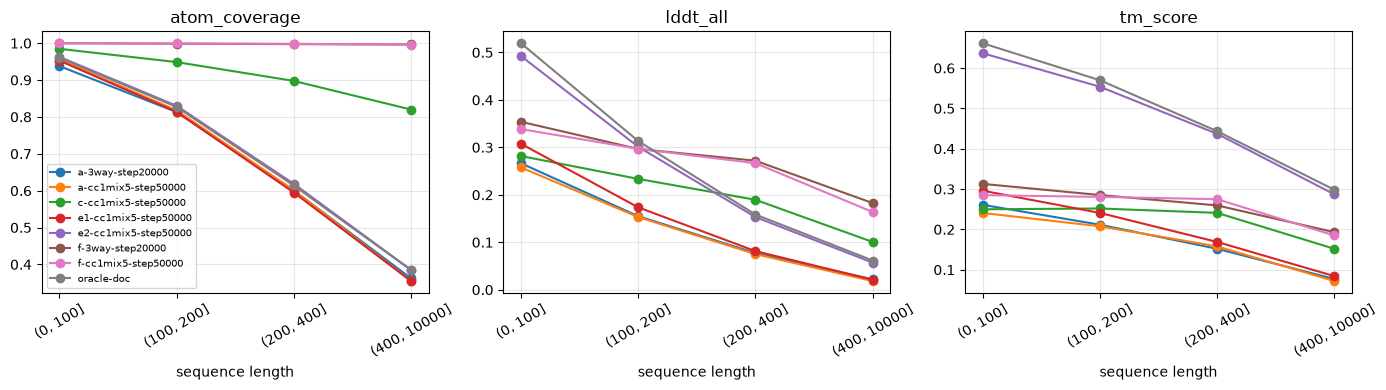

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for metric, axis in zip(["atom_coverage", "lddt_all", "tm_score"], axes):
    subset = scores[(scores.status == "ok") & scores.run.isin(VIEWABLE)]
    for run, group in subset.groupby("run"):
        binned = group.groupby(pd.cut(group.L, [0, 100, 200, 400, 10_000]),
                               observed=True)[metric].mean()
        axis.plot([str(i) for i in binned.index], binned.values, marker="o", label=run)
    axis.set_title(metric); axis.set_xlabel("sequence length"); axis.grid(alpha=0.3)
    axis.tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=7)
fig.tight_layout()